## Idaho SNOTEL Metadata and Gap Analysis (1980–2025)

## Introduction

The Snow Telemetry (SNOTEL) network is a long-standing hydrometeorological monitoring system operated by the Natural Resources Conservation Service (NRCS) of the USDA. It was originally designed to support water supply forecasting in snow-dominated regions of the western United States. SNOTEL stations primarily measure Snow Water Equivalent (SWE), snow depth, precipitation, air temperature, and, at selected locations, soil moisture, soil temperature, and other environmental variables. Because of their elevation, longevity, and focus on snowpack dynamics, SNOTEL stations play a critical role in hydrologic forecasting, drought assessment, and climate monitoring.

In Idaho, the official SNOTEL inventory includes 85 active stations. However, when cross-referenced with the Synoptic Data platform, only 14 stations appear in the Synoptic system. This discrepancy raises an important question:

### Why are only a small subset of Idaho SNOTEL stations represented in Synoptic?

 To address this question, we analyze:
 
	•	Data coverage percentage
	•	Number and length of data gaps
	•	Effective period of record (POR)
	•	Availability of key variables across stations
	•	Differences between stations that are included in Synoptic (syn_in) and those that are not (syn_out)

## The *objective* is to determine whether the SNOTEL stations currently absent from Synoptic differ in data quality, continuity, or variable availability, and whether they could reasonably be integrated into a broader Idaho hydrometeorological network that extends beyond the Synoptic framework.

Ultimately, this analysis seeks to inform the design of a more comprehensive and reliable hydrometeorological monitoring network, leveraging the full SNOTEL infrastructure rather than only the subset currently represented in Synoptic.

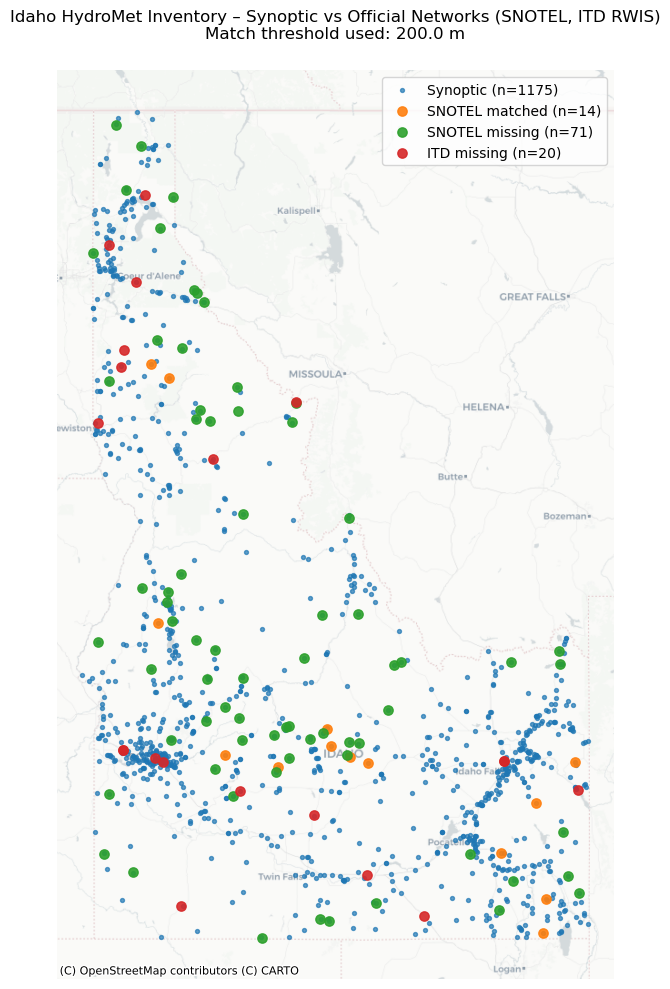

In [2]:
import os, json, requests
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt
import contextily as cx

# --------------------------
# CONFIG
# --------------------------
OUT_DIR = "out"
STATIONS_ALL_CSV = os.path.join(OUT_DIR, "stations_all.csv")
MATCH_SN_SY_CSV  = os.path.join(OUT_DIR, "matches_snotel_synoptic.csv")
OVERLAP_ITD_CSV  = os.path.join(OUT_DIR, "overlap_synoptic_vs_ITD_Rwis.csv")

MAX_DIST_M = 200.0  # for narrative; ITD overlap already computed with this threshold

# ITD ArcGIS REST query endpoint (from our network_audit notebook)
ITD_RWIS_QUERY = "https://gis.itd.idaho.gov/arcgisprod/rest/services/ArcGISOnline/RoadFeatureLayers/MapServer/6/query"

# --------------------------
# Helpers
# --------------------------
def to_gdf(df, lon_col="longitude", lat_col="latitude"):
    gdf = gpd.GeoDataFrame(
        df.copy(),
        geometry=[Point(xy) for xy in zip(df[lon_col], df[lat_col])],
        crs="EPSG:4326"
    )
    return gdf.to_crs(epsg=3857)

def fetch_itd_rwis_points(timeout: int = 60) -> pd.DataFrame:
    """
    Download RWIS point features from ITD ArcGIS REST as GeoJSON.
    """
    params = {
        "where": "1=1",
        "outFields": "*",
        "returnGeometry": "true",
        "f": "geojson",
        "resultRecordCount": 10000,
    }
    r = requests.get(ITD_RWIS_QUERY, params=params, timeout=timeout)
    r.raise_for_status()
    js = r.json()

    feats = js.get("features", [])
    rows = []
    for f in feats:
        geom = f.get("geometry") or {}
        props = f.get("properties") or {}
        coords = geom.get("coordinates")
        lon, lat = (coords[0], coords[1]) if isinstance(coords, list) and len(coords) >= 2 else (None, None)

        rows.append({
            "itd_site_id": props.get("SITEID") or props.get("siteid") or props.get("OBJECTID") or props.get("objectid"),
            "station_name": props.get("SITE") or props.get("site") or props.get("NAME") or props.get("Name"),
            "latitude": pd.to_numeric(lat, errors="coerce"),
            "longitude": pd.to_numeric(lon, errors="coerce"),
        })

    return pd.DataFrame(rows).dropna(subset=["latitude","longitude"]).reset_index(drop=True)

# --------------------------
# Load inputs
# --------------------------
stations_all = pd.read_csv(STATIONS_ALL_CSV)
df_syn = stations_all[stations_all["source"]=="SYNOPTIC"].dropna(subset=["latitude","longitude"]).copy()
df_snotel = stations_all[stations_all["source"]=="SNOTEL"].dropna(subset=["latitude","longitude"]).copy()

m_sn_sy = pd.read_csv(MATCH_SN_SY_CSV)
ov_itd  = pd.read_csv(OVERLAP_ITD_CSV)

# --------------------------
# Split SNOTEL matched vs missing (based on matches file)
# --------------------------
snotel_matched_ids = (
    m_sn_sy["SNOTEL_source_id"]
    .dropna()
    .astype(str)
    .str.strip()
    .unique()
)
df_snotel["source_station_id"] = df_snotel["source_station_id"].astype(str).str.strip()

df_snotel_matched = df_snotel[df_snotel["source_station_id"].isin(snotel_matched_ids)].copy()
df_snotel_missing = df_snotel[~df_snotel["source_station_id"].isin(snotel_matched_ids)].copy()

# --------------------------
# ITD missing (official ITD points minus those matched to Synoptic)
# --------------------------
itd_official = fetch_itd_rwis_points()
itd_official["itd_site_id"] = itd_official["itd_site_id"].astype(str).str.strip()

itd_matched_ids = (
    ov_itd["ITD_site_id"]
    .dropna()
    .astype(str)
    .str.strip()
    .unique()
)

itd_missing = itd_official[~itd_official["itd_site_id"].isin(itd_matched_ids)].copy()

# --------------------------
# Make GeoDataFrames
# --------------------------
gdf_syn = to_gdf(df_syn)
gdf_snotel_matched = to_gdf(df_snotel_matched)
gdf_snotel_missing = to_gdf(df_snotel_missing)
gdf_itd_missing = to_gdf(itd_missing)

# --------------------------
# Plot
# --------------------------
fig, ax = plt.subplots(figsize=(8, 10))

gdf_syn.plot(ax=ax, markersize=8, alpha=0.7, label=f"Synoptic (n={len(df_syn)})")
gdf_snotel_matched.plot(ax=ax, markersize=45, alpha=0.9, label=f"SNOTEL matched (n={len(df_snotel_matched)})")
gdf_snotel_missing.plot(ax=ax, markersize=45, alpha=0.9, label=f"SNOTEL missing (n={len(df_snotel_missing)})")
gdf_itd_missing.plot(ax=ax, markersize=45, alpha=0.9, label=f"ITD missing (n={len(itd_missing)})")

# basemap
cx.add_basemap(ax, source=cx.providers.CartoDB.Positron)

ax.set_axis_off()
ax.set_title("Idaho HydroMet Inventory – Synoptic vs Official Networks (SNOTEL, ITD RWIS)\n"
             f"Match threshold used: {MAX_DIST_M} m",
             pad=12)

ax.legend(loc="upper right", frameon=True)
plt.tight_layout()
plt.show()

In [3]:
import requests
import pandas as pd
from io import StringIO

def fetch_snotel_idaho_inventory():
    url = "https://wcc.sc.egov.usda.gov/nwcc/sntlsites.jsp?state=ID"
    r = requests.get(url, timeout=60)
    r.raise_for_status()

    # IMPORTANT: wrap HTML in a file-like buffer
    html_buf = StringIO(r.text)

    dfs = pd.read_html(html_buf)  # now it cannot be interpreted as a filename
    df = dfs[0].copy()

    df.columns = [str(c).strip().lower().replace(" ", "_") for c in df.columns]
    df["source"] = "SNOTEL_OFFICIAL"
    return df

df_snotel_official = fetch_snotel_idaho_inventory()
print("Official SNOTEL stations in Idaho:", len(df_snotel_official))
df_snotel_official.head()

Official SNOTEL stations in Idaho: 85


,ntwk,state,site_name,ts,start,lat,lon,elev,county,huc,source
0,SNTL,ID,Atlanta Summit (306),NaN,1978-October,43.76,-115.24,7570,Elmore,Bald Mountain Creek-Middle Fork Boise River (1...,SNOTEL_OFFICIAL
1,SNTL,ID,Banner Summit (312),NaN,1979-October,44.30,-115.23,7040,Boise,Canyon Creek (170501200202),SNOTEL_OFFICIAL
2,SNTL,ID,Bear Basin (319),NaN,1979-October,44.95,-116.14,5350,Adams,Little Goose Creek-Goose Creek (170602100104),SNOTEL_OFFICIAL
3,SNTL,ID,Bear Canyon (320),NaN,1979-October,43.74,-113.94,7920,Custer,Upper Star Hope Creek (170402180101),SNOTEL_OFFICIAL
4,SNTL,ID,Bear Mountain (323),NaN,1979-October,48.31,-116.07,5460,Bonner,Middle Lightning Creek (170102131202),SNOTEL_OFFICIAL


In [4]:
n_stations = len(df_snotel_official)
print("Official SNOTEL stations in Idaho:", n_stations)

Official SNOTEL stations in Idaho: 85


In [5]:
df_snotel_official["station_id"] = (
    df_snotel_official["site_name"].astype(str).str.extract(r"\((\d+)\)")[0]
)

df_snotel_official["start_year"] = (
    df_snotel_official["start"].astype(str).str.extract(r"(\d{4})")[0].astype(float)
)

current_year = pd.Timestamp.now().year
df_snotel_official["por_years"] = current_year - df_snotel_official["start_year"]

In [6]:
# Example logic if using metloom metadata
key_vars = ["SWE", "SNWD", "TAVG", "PREC"]

# You would compute coverage by checking availability per station

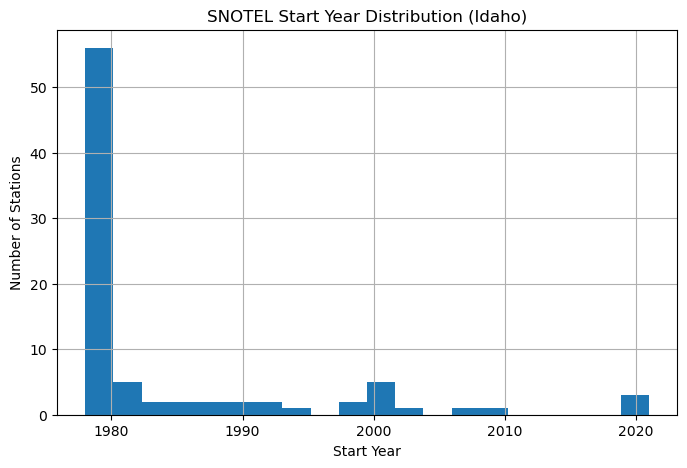

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
df_snotel_official["start_year"].hist(bins=20)
plt.xlabel("Start Year")
plt.ylabel("Number of Stations")
plt.title("SNOTEL Start Year Distribution (Idaho)")
plt.show()

In [8]:

df_snotel_official

,ntwk,state,site_name,ts,start,lat,lon,elev,county,huc,source,station_id,start_year,por_years
0,SNTL,ID,Atlanta Summit (306),NaN,1978-October,43.76,-115.24,7570,Elmore,Bald Mountain Creek-Middle Fork Boise River (1...,SNOTEL_OFFICIAL,306,1978.0,48.0
1,SNTL,ID,Banner Summit (312),NaN,1979-October,44.30,-115.23,7040,Boise,Canyon Creek (170501200202),SNOTEL_OFFICIAL,312,1979.0,47.0
2,SNTL,ID,Bear Basin (319),NaN,1979-October,44.95,-116.14,5350,Adams,Little Goose Creek-Goose Creek (170602100104),SNOTEL_OFFICIAL,319,1979.0,47.0
3,SNTL,ID,Bear Canyon (320),NaN,1979-October,43.74,-113.94,7920,Custer,Upper Star Hope Creek (170402180101),SNOTEL_OFFICIAL,320,1979.0,47.0
4,SNTL,ID,Bear Mountain (323),NaN,1979-October,48.31,-116.07,5460,Bonner,Middle Lightning Creek (170102131202),SNOTEL_OFFICIAL,323,1979.0,47.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80,SNTL,ID,Vienna Mine (845),NaN,1978-October,43.80,-114.85,8930,Blaine,Smiley Creek (170602010201),SNOTEL_OFFICIAL,845,1978.0,48.0
81,SNTL,ID,West Branch (855),NaN,1979-October,45.07,-116.45,5590,Adams,Upper Weiser River (170501240201),SNOTEL_OFFICIAL,855,1979.0,47.0
82,SNTL,ID,White Elephant (860),NaN,1979-October,44.53,-111.41,7670,Fremont,Coffee Pot Creek-Henrys Fork (170402020305),SNOTEL_OFFICIAL,860,1979.0,47.0
83,SNTL,ID,Wildhorse Divide (867),NaN,1979-October,42.76,-112.48,6480,Bannock,Mink Creek (170402080504),SNOTEL_OFFICIAL,867,1979.0,47.0


In [9]:
import re
import pandas as pd

matches = pd.read_csv("out/matches_snotel_synoptic.csv")

# estrai numero stazione
matches["station_id"] = matches["SNOTEL_uid"].str.extract(r"(\d+)").astype(float)

matched_ids = set(matches["station_id"].dropna().astype(int))

print("Unique matched SNOTEL IDs:", len(matched_ids))

Unique matched SNOTEL IDs: 14


In [10]:
import pandas as pd
import numpy as np
import re

df = df_snotel_official.copy()

# Standardize numeric columns
df["lat"]  = pd.to_numeric(df["lat"], errors="coerce")
df["lon"]  = pd.to_numeric(df["lon"], errors="coerce")
df["elev_ft"] = pd.to_numeric(df["elev"], errors="coerce")
df["elev_m"]  = df["elev_ft"] * 0.3048

# Station ID from site_name "Atlanta Summit (306)"
df["station_id"] = df["site_name"].astype(str).str.extract(r"\((\d+)\)")[0]

# Triplet (metloom uses e.g. "306:ID:SNTL")
df["station_triplet"] = df["station_id"].apply(lambda x: f"{x}:ID:SNTL" if pd.notna(x) else pd.NA)

# Parse start year (from "1978-October")
df["start_year"] = pd.to_numeric(df["start"].astype(str).str.extract(r"(\d{4})")[0], errors="coerce")
current_year = pd.Timestamp.utcnow().year
df["por_years_approx"] = current_year - df["start_year"]

# Keep a clean inventory table
cols = ["station_triplet","station_id","site_name","lat","lon","elev_ft","elev_m","county","huc","start","start_year","por_years_approx","source"]
df_station_meta = df[cols].copy()

df_station_meta.to_csv("out/snotel_official_inventory_idaho_clean.csv", index=False)
print("[OUT] out/snotel_official_inventory_idaho_clean.csv", len(df_station_meta))
df_station_meta.head()

[OUT] out/snotel_official_inventory_idaho_clean.csv 85


,station_triplet,station_id,site_name,lat,lon,elev_ft,elev_m,county,huc,start,start_year,por_years_approx,source
0,306:ID:SNTL,306,Atlanta Summit (306),43.76,-115.24,7570,2307.336,Elmore,Bald Mountain Creek-Middle Fork Boise River (1...,1978-October,1978,48,SNOTEL_OFFICIAL
1,312:ID:SNTL,312,Banner Summit (312),44.30,-115.23,7040,2145.792,Boise,Canyon Creek (170501200202),1979-October,1979,47,SNOTEL_OFFICIAL
2,319:ID:SNTL,319,Bear Basin (319),44.95,-116.14,5350,1630.680,Adams,Little Goose Creek-Goose Creek (170602100104),1979-October,1979,47,SNOTEL_OFFICIAL
3,320:ID:SNTL,320,Bear Canyon (320),43.74,-113.94,7920,2414.016,Custer,Upper Star Hope Creek (170402180101),1979-October,1979,47,SNOTEL_OFFICIAL
4,323:ID:SNTL,323,Bear Mountain (323),48.31,-116.07,5460,1664.208,Bonner,Middle Lightning Creek (170102131202),1979-October,1979,47,SNOTEL_OFFICIAL


In [11]:
import re
import pandas as pd

matches = pd.read_csv("out/matches_snotel_synoptic.csv")

# estrai numero stazione
matches["station_id"] = matches["SNOTEL_uid"].str.extract(r"(\d+)").astype(float)

matched_ids = set(matches["station_id"].dropna().astype(int))

print("Unique matched SNOTEL IDs:", len(matched_ids))

Unique matched SNOTEL IDs: 14


In [12]:
df_snotel_official["station_id"] = df_snotel_official["station_id"].astype(int)

df_snotel_official["syn_in"] = df_snotel_official["station_id"].isin(matched_ids)

df_snotel_official["syn_out"] = ~df_snotel_official["syn_in"]

In [13]:
df_snotel_official["syn_in"].value_counts()

syn_in
False    71
True     14
Name: count, dtype: int64

In [14]:
df_snotel_official.to_csv(
    "out/snotel_official_inventory_with_synoptic_flag.csv",
    index=False
)

print("[OUT] snotel_official_inventory_with_synoptic_flag.csv")

[OUT] snotel_official_inventory_with_synoptic_flag.csv


In [15]:
df_snotel_official

,ntwk,state,site_name,ts,start,lat,lon,elev,county,huc,source,station_id,start_year,por_years,syn_in,syn_out
0,SNTL,ID,Atlanta Summit (306),NaN,1978-October,43.76,-115.24,7570,Elmore,Bald Mountain Creek-Middle Fork Boise River (1...,SNOTEL_OFFICIAL,306,1978.0,48.0,False,True
1,SNTL,ID,Banner Summit (312),NaN,1979-October,44.30,-115.23,7040,Boise,Canyon Creek (170501200202),SNOTEL_OFFICIAL,312,1979.0,47.0,False,True
2,SNTL,ID,Bear Basin (319),NaN,1979-October,44.95,-116.14,5350,Adams,Little Goose Creek-Goose Creek (170602100104),SNOTEL_OFFICIAL,319,1979.0,47.0,False,True
3,SNTL,ID,Bear Canyon (320),NaN,1979-October,43.74,-113.94,7920,Custer,Upper Star Hope Creek (170402180101),SNOTEL_OFFICIAL,320,1979.0,47.0,False,True
4,SNTL,ID,Bear Mountain (323),NaN,1979-October,48.31,-116.07,5460,Bonner,Middle Lightning Creek (170102131202),SNOTEL_OFFICIAL,323,1979.0,47.0,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80,SNTL,ID,Vienna Mine (845),NaN,1978-October,43.80,-114.85,8930,Blaine,Smiley Creek (170602010201),SNOTEL_OFFICIAL,845,1978.0,48.0,False,True
81,SNTL,ID,West Branch (855),NaN,1979-October,45.07,-116.45,5590,Adams,Upper Weiser River (170501240201),SNOTEL_OFFICIAL,855,1979.0,47.0,False,True
82,SNTL,ID,White Elephant (860),NaN,1979-October,44.53,-111.41,7670,Fremont,Coffee Pot Creek-Henrys Fork (170402020305),SNOTEL_OFFICIAL,860,1979.0,47.0,False,True
83,SNTL,ID,Wildhorse Divide (867),NaN,1979-October,42.76,-112.48,6480,Bannock,Mink Creek (170402080504),SNOTEL_OFFICIAL,867,1979.0,47.0,False,True


In [16]:
from metloom.pointdata.snotel import SnotelPointData

print(type(SnotelPointData.ALLOWED_VARIABLES))
print([v for v in dir(SnotelPointData.ALLOWED_VARIABLES) if v.isupper() and not v.startswith("_")])

<class 'type'>
['PRECIPITATION', 'PRECIPITATIONACCUM', 'RH', 'SNOWDEPTH', 'SOILMOISTURE20IN', 'SOILMOISTURE2IN', 'SOILMOISTURE4IN', 'SOILMOISTURE8IN', 'STREAMVOLUMEADJ', 'STREAMVOLUMEOBS', 'SWE', 'TEMP', 'TEMPAVG', 'TEMPGROUND20IN', 'TEMPGROUND2IN', 'TEMPGROUND4IN', 'TEMPGROUND8IN', 'TEMPMAX', 'TEMPMIN', 'TEMPPROFILE0IN', 'TEMPPROFILE102IN', 'TEMPPROFILE110IN', 'TEMPPROFILE118IN', 'TEMPPROFILE126IN', 'TEMPPROFILE16IN', 'TEMPPROFILE24IN', 'TEMPPROFILE31IN', 'TEMPPROFILE39IN', 'TEMPPROFILE47IN', 'TEMPPROFILE55IN', 'TEMPPROFILE63IN', 'TEMPPROFILE71IN', 'TEMPPROFILE79IN', 'TEMPPROFILE87IN', 'TEMPPROFILE8IN', 'TEMPPROFILE94IN', 'TEMPPROFILENEG8IN']


## Variables description

from datetime import datetime

START = datetime(1980, 1, 1)
END   = datetime(2025, 12, 31)
#START = datetime(1980, 1, 1)SNOTEL Available Variables (Metloom Interface)

The following variables represent the set of meteorological, snow, soil, and hydrological measurements available through the SNOTEL network via the metloom interface. These variables capture surface snowpack dynamics, atmospheric conditions, soil processes, and in some cases streamflow observations.

⸻

❄ Snowpack Variables

## SWE

Snow Water Equivalent
The amount of liquid water contained within the snowpack.
Typically measured in inches or millimeters of water equivalent.
This is the primary variable for hydrologic forecasting and water resource assessment.

## SNOWDEPTH

Snow Depth
The physical height of the snowpack measured from the ground surface.
Represents snow accumulation but does not account for density variations.

⸻

🌧 Precipitation Variables

## PRECIPITATION

Daily incremental precipitation (liquid equivalent).
Represents the amount of precipitation recorded during a given time step.

## PRECIPITATIONACCUM

Cumulative precipitation since the beginning of the water year.
Useful for seasonal water balance and accumulation studies.

⸻

🌡 Air Temperature Variables

## TEMP

Instantaneous air temperature measurement.

## TEMPAVG

Daily average air temperature (reported as “AVG AIR TEMP” in returned data).
Commonly used in snowmelt modeling and degree-day calculations.

## TEMPMAX

Daily maximum air temperature.

## TEMPMIN

Daily minimum air temperature.

⸻

💧 Atmospheric Moisture

## RH

Relative Humidity.
Represents the percentage of moisture in the air relative to saturation.

⸻

🌱 Soil Moisture Variables

These represent volumetric soil water content at different depths (depths in inches):

	•   SOILMOISTURE2IN
	•	SOILMOISTURE4IN
	•	SOILMOISTURE8IN
	•	SOILMOISTURE20IN

These measurements are useful for studying infiltration, soil water storage, and snowmelt–soil interactions.

⸻

🌡 Soil Temperature Variables

Ground temperature measurements at specified depths (in inches):

	•	TEMPGROUND2IN
	•	TEMPGROUND4IN
	•	TEMPGROUND8IN
	•	TEMPGROUND20IN

These are often used in freeze–thaw and soil thermal regime studies.

⸻

🌡 Vertical Temperature Profiles

These represent detailed vertical soil or subsurface temperature measurements at multiple depths:

	•	TEMPPROFILE0IN
	•	TEMPPROFILE8IN
	•	TEMPPROFILE16IN
	•	TEMPPROFILE24IN
	•	TEMPPROFILE31IN
	•	TEMPPROFILE39IN
	•	TEMPPROFILE47IN
	•	TEMPPROFILE55IN
	•	TEMPPROFILE63IN
	•	TEMPPROFILE71IN
	•	TEMPPROFILE79IN
	•	TEMPPROFILE87IN
	•	TEMPPROFILE94IN
	•	TEMPPROFILE102IN
	•	TEMPPROFILE110IN
	•	TEMPPROFILE118IN
	•	TEMPPROFILE126IN
	•	TEMPPROFILENEG8IN

Depths are reported in inches below the ground surface (except NEG8IN, which may represent a sensor above the ground or near-surface air). These profiles support detailed studies of soil thermal gradients, frost depth, and subsurface energy exchange.

⸻

🌊 Streamflow Variables

## STREAMVOLUMEOBS

Observed stream volume.
Represents measured streamflow where available.

## STREAMVOLUMEADJ

Adjusted stream volume.
Streamflow corrected for calibration or quality-control adjustments.

Not all SNOTEL stations include streamflow measurements.

⸻

## Summary

The SNOTEL variable set spans:
	•	Snowpack dynamics (SWE, Snow Depth)
	•	Precipitation accumulation
	•	Atmospheric temperature and humidity
	•	Soil moisture and soil temperature at multiple depths
	•	Detailed subsurface thermal profiles
	•	Streamflow (where instrumented)

For hydrologic and snow-energy studies, the core variables are typically:
	•	SWE
	•	SNOWDEPTH
	•	PRECIPITATIONACCUM
	•	TEMPAVG
	•	TEMPMAX
	•	TEMPMIN

Soil and temperature profile variables are primarily used in advanced snowmelt and land–surface process studies.
#END   = datetime(2025, 12, 31)

In [21]:
import os
import re
import numpy as np
import pandas as pd

# =========================
# 1) Load existing output
# =========================
OUT_CSV = "out/snotel_idaho_variable_metadata_por_gaps_1980.csv"  # <-- quello già prodotto

if not os.path.exists(OUT_CSV):
    raise FileNotFoundError(
        f"Non trovo {OUT_CSV}. Controlla percorso/nome file oppure copialo in out/."
    )

df_snotel_varmeta = pd.read_csv(OUT_CSV)

# parse dates if present
for c in ["por_start", "por_end"]:
    if c in df_snotel_varmeta.columns:
        df_snotel_varmeta[c] = pd.to_datetime(df_snotel_varmeta[c], errors="coerce")

print("[OK] loaded:", OUT_CSV, "rows:", len(df_snotel_varmeta))
df_snotel_varmeta.head()

[OK] loaded: out/snotel_idaho_variable_metadata_por_gaps_1980.csv rows: 340


,station_triplet,variable,column_used,coverage_pct,por_start,por_end,por_years,n_gaps,max_gap_days,note,error
0,306:ID:SNTL,"SensorDescription(code='WTEQ', name='SWE', des...",SWE,97.57,1980-10-01 08:00:00+00:00,2025-12-31 08:00:00+00:00,45.248,5,288,NaN,NaN
1,306:ID:SNTL,"SensorDescription(code='SNWD', name='SNOWDEPTH...",SNOWDEPTH,64.58,1996-10-04 08:00:00+00:00,2025-12-31 08:00:00+00:00,29.240,7,5847,NaN,NaN
2,306:ID:SNTL,"SensorDescription(code='PRCPSA', name='PRECIPI...",PRECIPITATION,99.24,1980-10-01 08:00:00+00:00,2025-12-31 08:00:00+00:00,45.248,1,125,NaN,NaN
3,306:ID:SNTL,"SensorDescription(code='TAVG', name='AVG AIR T...",AVG AIR TEMP,80.87,1988-09-14 08:00:00+00:00,2025-12-31 08:00:00+00:00,37.295,113,2905,NaN,NaN
4,312:ID:SNTL,"SensorDescription(code='WTEQ', name='SWE', des...",SWE,100.00,1980-10-01 08:00:00+00:00,2025-12-31 08:00:00+00:00,45.248,0,0,NaN,NaN


In [22]:
df_snotel_varmeta["station_id"] = (
    df_snotel_varmeta["station_triplet"]
    .str.extract(r"(\d+)")[0]
    .astype(int)
)

In [23]:
df_snotel_varmeta = df_snotel_varmeta.merge(
    df_snotel_official[["station_id", "syn_in"]],
    on="station_id",
    how="left"
)

df_snotel_varmeta["syn_in"] = df_snotel_varmeta["syn_in"].fillna(False)

In [24]:
df_snotel_varmeta

,station_triplet,variable,column_used,coverage_pct,por_start,por_end,por_years,n_gaps,max_gap_days,note,error,station_id,syn_in
0,306:ID:SNTL,"SensorDescription(code='WTEQ', name='SWE', des...",SWE,97.57,1980-10-01 08:00:00+00:00,2025-12-31 08:00:00+00:00,45.248,5,288,NaN,NaN,306,False
1,306:ID:SNTL,"SensorDescription(code='SNWD', name='SNOWDEPTH...",SNOWDEPTH,64.58,1996-10-04 08:00:00+00:00,2025-12-31 08:00:00+00:00,29.240,7,5847,NaN,NaN,306,False
2,306:ID:SNTL,"SensorDescription(code='PRCPSA', name='PRECIPI...",PRECIPITATION,99.24,1980-10-01 08:00:00+00:00,2025-12-31 08:00:00+00:00,45.248,1,125,NaN,NaN,306,False
3,306:ID:SNTL,"SensorDescription(code='TAVG', name='AVG AIR T...",AVG AIR TEMP,80.87,1988-09-14 08:00:00+00:00,2025-12-31 08:00:00+00:00,37.295,113,2905,NaN,NaN,306,False
4,312:ID:SNTL,"SensorDescription(code='WTEQ', name='SWE', des...",SWE,100.00,1980-10-01 08:00:00+00:00,2025-12-31 08:00:00+00:00,45.248,0,0,NaN,NaN,312,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
335,867:ID:SNTL,"SensorDescription(code='TAVG', name='AVG AIR T...",AVG AIR TEMP,96.43,1982-12-21 08:00:00+00:00,2025-12-31 08:00:00+00:00,43.028,80,355,NaN,NaN,867,False
336,871:ID:SNTL,"SensorDescription(code='WTEQ', name='SWE', des...",SWE,100.00,1990-09-26 08:00:00+00:00,2025-12-31 08:00:00+00:00,35.264,0,0,NaN,NaN,871,False
337,871:ID:SNTL,"SensorDescription(code='SNWD', name='SNOWDEPTH...",SNOWDEPTH,63.88,2003-05-29 08:00:00+00:00,2025-12-31 08:00:00+00:00,22.593,4,4628,NaN,NaN,871,False
338,871:ID:SNTL,"SensorDescription(code='PRCPSA', name='PRECIPI...",PRECIPITATION,99.96,1990-10-01 08:00:00+00:00,2025-12-31 08:00:00+00:00,35.250,1,5,NaN,NaN,871,False


## SNOTEL Variable Metadata Dataset (df_snotel_varmeta)

This dataset contains summary statistics for each SNOTEL station × variable over the selected analysis window (e.g., 2020–2025).

Each row represents one variable at one station.

⸻

Column Descriptions

### station_triplet

Unique SNOTEL station identifier in the format:
<station_id>:<state>:SNTL
Example:
306:ID:SNTL

This is the official NRCS station identifier and is the primary key for station-level analysis.

⸻

### coverage_pct

Percentage of valid (non-missing) daily observations within the selected time window.

Formula:
coverage\_pct = 100 \times \frac{\text{valid daily records}}{\text{total days in window}}

Interpretation:
	•	100% → no missing data
	•	<95% → noticeable data gaps
	•	<90% → potentially unreliable for long-term analysis
por_start

Start date of the valid Period of Record (POR) within the selected window.

This is the first valid (non-NaN) timestamp found in the time window.

⸻

### por_end

End date of the valid Period of Record within the selected window.

This is the last valid (non-NaN) timestamp.

⸻

### por_years

Length (in years) of the valid period between por_start and por_end.

Computed as:

\frac{por\_end - por\_start}{365.25}

Important:
This does not measure full station lifetime — only the effective usable window in your selected period.

⸻

### n_gaps

Number of missing data sequences (continuous runs of NaN values).

Example:
If data are missing:
Jan 5–Jan 10
Mar 1–Mar 3
Then:
n_gaps = 2

⸻

### max_gap_days

Length (in days) of the longest continuous missing data period.

This is critical for:
	•	Hydrologic modeling robustness
	•	Machine learning input stability
	•	Snowmelt modeling reliability

Example:
max_gap_days = 125
means the station had a 125-day continuous outage.
note

Text flag describing special conditions.

Typical values:
	•	"" → normal

	•	"variable_stats_failed" → error during metric computation

⸻

### error

Contains error message if something failed during processing.
Normally empty for valid rows.

⸻

### station_id

Integer version of the station identifier extracted from station_triplet.

Example:
    306
    Used for merging with external datasets (e.g., Synoptic match file).
        syn_in_x

Intermediate merge artifact (can usually be dropped).

⸻

### syn_in_y

Intermediate merge artifact (can usually be dropped).

⸻

### syn_in

Final boolean flag indicating whether the SNOTEL station was matched to a Synoptic station.

Values:
	•	True → SNOTEL station has a corresponding Synoptic entry
	•	False → No match found in Synoptic dataset

This allows comparison of:
	•	Stations included in Synoptic integration
	•	Stations excluded from Synoptic

⸻


In [25]:
df_snotel_varmeta.groupby(["column_used", "syn_in"])["coverage_pct"].mean()

column_used    syn_in
AVG AIR TEMP   False     89.060000
               True      88.597857
PRECIPITATION  False     99.342254
               True      98.977143
SNOWDEPTH      False     55.155634
               True      56.097857
SWE            False     99.071127
               True      98.489286
Name: coverage_pct, dtype: float64

## Mean  coverage per variable 

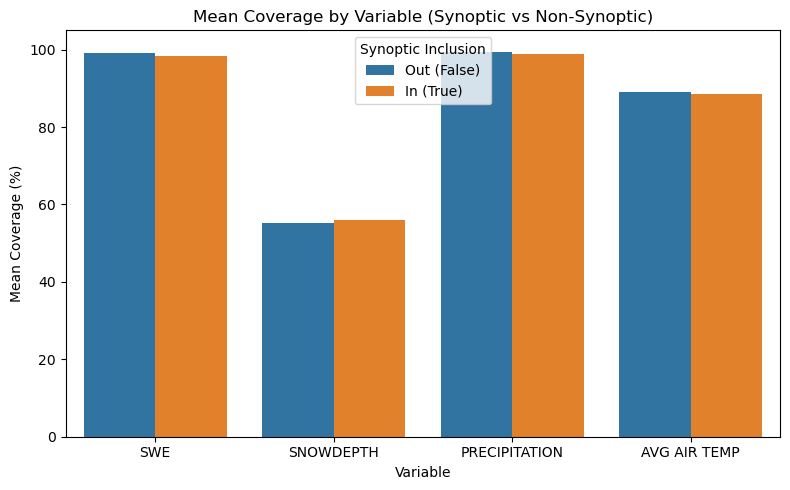

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calcola media coverage
df_plot = (
    df_snotel_varmeta
    .groupby(["column_used", "syn_in"])["coverage_pct"]
    .mean()
    .reset_index()
)

# Ordine variabili
var_order = ["SWE", "SNOWDEPTH", "PRECIPITATION", "AVG AIR TEMP"]
df_plot["column_used"] = pd.Categorical(df_plot["column_used"], categories=var_order, ordered=True)

plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=df_plot,
    x="column_used",
    y="coverage_pct",
    hue="syn_in"
)

plt.ylabel("Mean Coverage (%)")
plt.xlabel("Variable")
plt.title("Mean Coverage by Variable (Synoptic vs Non-Synoptic)")
plt.ylim(0, 105)

# Rinomina legenda in modo corretto
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, ["Out (False)", "In (True)"], title="Synoptic Inclusion")

plt.tight_layout()
plt.show()

In [28]:
df_snotel_varmeta.groupby("column_used")["coverage_pct"].describe()

,count,mean,std,min,25%,50%,75%,max
column_used,,,,,,,,
AVG AIR TEMP,85.0,88.983882,8.041811,78.80,82.05,84.12,98.55,99.94
PRECIPITATION,85.0,99.282118,1.570192,88.47,99.35,99.88,99.99,100.00
SNOWDEPTH,85.0,55.310824,22.729402,18.42,38.99,54.25,63.88,99.99
SWE,85.0,98.975294,2.300428,87.44,98.76,99.97,100.00,100.00


## coverage up to 95%

In [29]:
(df_snotel_varmeta["coverage_pct"] > 95).groupby(
    df_snotel_varmeta["column_used"]
).mean() * 100

column_used
AVG AIR TEMP     36.470588
PRECIPITATION    96.470588
SNOWDEPTH        14.117647
SWE              96.470588
Name: coverage_pct, dtype: float64

## gap severity

In [30]:
df_snotel_varmeta.groupby("column_used")[["n_gaps","max_gap_days"]].median()

,n_gaps,max_gap_days
column_used,,
AVG AIR TEMP,46.0,2457.0
PRECIPITATION,1.0,11.0
SNOWDEPTH,2.0,7133.0
SWE,1.0,1.0


In [31]:
df_snotel_varmeta.groupby("column_used")["max_gap_days"].quantile(0.95)

column_used
AVG AIR TEMP      3164.8
PRECIPITATION      365.0
SNOWDEPTH        12299.8
SWE                365.0
Name: max_gap_days, dtype: float64

In [32]:
df_snotel_varmeta[df_snotel_varmeta["column_used"]=="AVG AIR TEMP"]["max_gap_days"].describe()

count      85.000000
mean     1662.305882
std      1313.413120
min         1.000000
25%        46.000000
50%      2457.000000
75%      2864.000000
max      3234.000000
Name: max_gap_days, dtype: float64

In [33]:
df_snotel_varmeta[
    (df_snotel_varmeta["column_used"]=="AVG AIR TEMP") &
    (df_snotel_varmeta["max_gap_days"] > 30)
][["station_triplet","max_gap_days","coverage_pct"]]

,station_triplet,max_gap_days,coverage_pct
3,306:ID:SNTL,2905,80.87
7,312:ID:SNTL,2722,83.10
11,319:ID:SNTL,2864,82.02
15,320:ID:SNTL,1039,92.49
19,323:ID:SNTL,2772,80.88
...,...,...,...
319,979:ID:SNTL,32,99.45
323,845:ID:SNTL,2678,82.79
327,855:ID:SNTL,2699,82.90
331,860:ID:SNTL,2477,84.36


In [34]:
df_snotel_varmeta[
    (df_snotel_varmeta["column_used"]=="AVG AIR TEMP")
    & (df_snotel_varmeta["max_gap_days"] > 30)
][["station_triplet","syn_in","max_gap_days"]]

,station_triplet,syn_in,max_gap_days
3,306:ID:SNTL,False,2905
7,312:ID:SNTL,False,2722
11,319:ID:SNTL,False,2864
15,320:ID:SNTL,False,1039
19,323:ID:SNTL,False,2772
...,...,...,...
319,979:ID:SNTL,False,32
323,845:ID:SNTL,False,2678
327,855:ID:SNTL,False,2699
331,860:ID:SNTL,False,2477


In [35]:
df_snotel_varmeta.groupby("column_used")["por_years"].describe()

,count,mean,std,min,25%,50%,75%,max
column_used,,,,,,,,
AVG AIR TEMP,85.0,35.097071,8.051548,4.235,36.372,37.251,37.410,45.391
PRECIPITATION,85.0,39.464400,9.856449,4.233,39.250,44.249,44.249,45.990
SNOWDEPTH,85.0,20.433953,6.469600,4.233,15.422,22.593,25.352,29.394
SWE,85.0,39.552341,9.911021,4.233,39.250,44.249,45.248,45.990


In [37]:
import os
import pandas as pd
import numpy as np

# =========================
# 1) Paths
# =========================
OUT_CSV  = "out/snotel_idaho_variable_metadata_por_gaps_1980.csv"   # 1980–2025
OUT_CSV1 = "out/snotel_idaho_variable_metadata_por_gaps.csv"        # 2020–2025 (il tuo recente)

for p in [OUT_CSV, OUT_CSV1]:
    if not os.path.exists(p):
        raise FileNotFoundError(f"Non trovo {p}. Controlla percorso/nome file.")

# =========================
# 2) Load
# =========================
df_80 = pd.read_csv(OUT_CSV)
df_20 = pd.read_csv(OUT_CSV1)

# parse dates if present
for df in [df_80, df_20]:
    for c in ["por_start", "por_end", "full_start", "full_end"]:
        if c in df.columns:
            df[c] = pd.to_datetime(df[c], errors="coerce")

# =========================
# 3) Robust key: station_triplet + column_used
# =========================
# Some runs store "variable" as long SensorDescription; column_used is stable ("SWE", "SNOWDEPTH", ...)
for df in [df_80, df_20]:
    if "column_used" not in df.columns:
        raise KeyError("Manca 'column_used' in uno dei file. Serve per fare merge robusto.")

# keep only one syn_in column if duplicated in df_20
if "syn_in_x" in df_20.columns or "syn_in_y" in df_20.columns:
    # try to collapse to single syn_in
    if "syn_in" not in df_20.columns:
        # pick first available
        cand = [c for c in ["syn_in_x", "syn_in_y"] if c in df_20.columns]
        if cand:
            df_20["syn_in"] = df_20[cand].bfill(axis=1).iloc[:, 0]

# =========================
# 4) Rename metrics to avoid collision
# =========================
METRICS = ["coverage_pct","por_start","por_end","por_years","n_gaps","max_gap_days","note","error"]

def rename_metrics(df, suffix):
    ren = {}
    for m in METRICS:
        if m in df.columns:
            ren[m] = f"{m}_{suffix}"
    return df.rename(columns=ren)

df_80r = rename_metrics(df_80, "1980")
df_20r = rename_metrics(df_20, "2020")

# =========================
# 5) Reduce columns before merge (avoid huge duplicates)
# =========================
keep_keys = ["station_triplet", "column_used"]
keep_80 = keep_keys + [c for c in df_80r.columns if c.endswith("_1980")] + [c for c in ["station_id"] if c in df_80r.columns]
keep_20 = keep_keys + [c for c in df_20r.columns if c.endswith("_2020")] + [c for c in ["station_id","syn_in"] if c in df_20r.columns]

df_80r = df_80r[keep_80].copy()
df_20r = df_20r[keep_20].copy()

# =========================
# 6) Merge
# =========================
df_combined = df_20r.merge(df_80r, on=keep_keys, how="left", suffixes=("", ""))

# optional: if station_id exists in both, fill
if "station_id_x" in df_combined.columns and "station_id_y" in df_combined.columns:
    df_combined["station_id"] = df_combined["station_id_x"].fillna(df_combined["station_id_y"])
    df_combined = df_combined.drop(columns=["station_id_x","station_id_y"])

print("[OK] combined rows:", len(df_combined))
df_combined.head()

[OK] combined rows: 340


,station_triplet,column_used,coverage_pct_2020,por_start_2020,por_end_2020,por_years_2020,n_gaps_2020,max_gap_days_2020,note_2020,error_2020,coverage_pct_1980,por_start_1980,por_end_1980,por_years_1980,n_gaps_1980,max_gap_days_1980,note_1980,error_1980
0,306:ID:SNTL,SWE,100.00,2020-01-01 08:00:00+00:00,2025-12-31 08:00:00+00:00,5.999,0.0,0.0,NaN,NaN,97.57,1980-10-01 08:00:00+00:00,2025-12-31 08:00:00+00:00,45.248,5,288,NaN,NaN
1,306:ID:SNTL,SNOWDEPTH,100.00,2020-01-01 08:00:00+00:00,2025-12-31 08:00:00+00:00,5.999,0.0,0.0,NaN,NaN,64.58,1996-10-04 08:00:00+00:00,2025-12-31 08:00:00+00:00,29.240,7,5847,NaN,NaN
2,306:ID:SNTL,PRECIPITATION,94.30,2020-01-01 08:00:00+00:00,2025-12-31 08:00:00+00:00,5.999,1.0,125.0,NaN,NaN,99.24,1980-10-01 08:00:00+00:00,2025-12-31 08:00:00+00:00,45.248,1,125,NaN,NaN
3,306:ID:SNTL,AVG AIR TEMP,99.54,2020-01-01 08:00:00+00:00,2025-12-31 08:00:00+00:00,5.999,2.0,9.0,NaN,NaN,80.87,1988-09-14 08:00:00+00:00,2025-12-31 08:00:00+00:00,37.295,113,2905,NaN,NaN
4,312:ID:SNTL,SWE,100.00,2020-01-01 08:00:00+00:00,2025-12-31 08:00:00+00:00,5.999,0.0,0.0,NaN,NaN,100.00,1980-10-01 08:00:00+00:00,2025-12-31 08:00:00+00:00,45.248,0,0,NaN,NaN


In [42]:
import pandas as pd

# 1) station_id da triplet (es. "306:ID:SNTL" -> 306)
df_combined["station_id"] = (
    df_combined["station_triplet"]
    .astype(str)
    .str.extract(r"^(\d+):")[0]
    .astype("Int64")
)

# 2) lookup ufficiale (evita duplicati)
lookup = (
    df_snotel_official[["station_id", "syn_in"]]
    .drop_duplicates("station_id")
    .assign(
        station_id=lambda d: pd.to_numeric(d["station_id"], errors="coerce").astype("Int64"),
        syn_in=lambda d: d["syn_in"].astype(bool)
    )
)

# 3) merge su df_combined
df_combined = df_combined.merge(
    lookup,
    on="station_id",
    how="left"
)

# 4) fillna -> False e cast a boolean
df_combined["syn_in"] = df_combined["syn_in"].fillna(False).astype(bool)

df_combined[["station_triplet", "station_id", "syn_in"]].head()

,station_triplet,station_id,syn_in
0,306:ID:SNTL,306,False
1,306:ID:SNTL,306,False
2,306:ID:SNTL,306,False
3,306:ID:SNTL,306,False
4,312:ID:SNTL,312,False


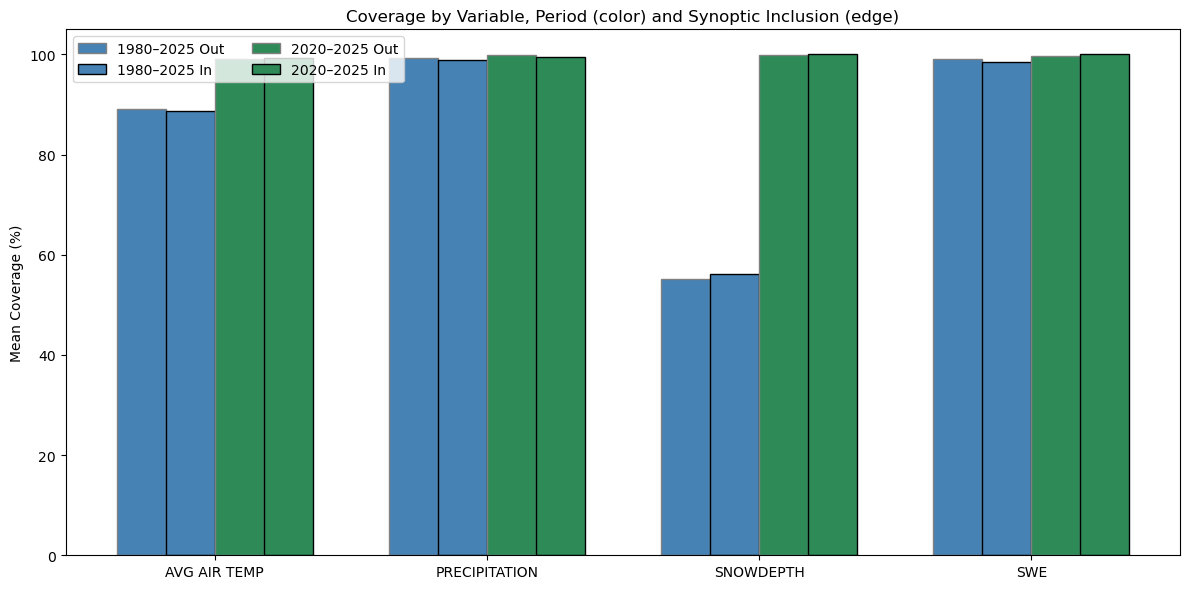

In [44]:
import matplotlib.pyplot as plt
import numpy as np

summary = (
    df_combined
    .groupby(["column_used", "syn_in"])[
        ["coverage_pct_1980", "coverage_pct_2020"]
    ]
    .mean()
    .reset_index()
)

variables = summary["column_used"].unique()
x = np.arange(len(variables))
width = 0.18

fig, ax = plt.subplots(figsize=(12,6))

for i, var in enumerate(variables):

    sub = summary[summary["column_used"] == var]

    cov80_out = sub.loc[sub["syn_in"]==False, "coverage_pct_1980"].values
    cov80_in  = sub.loc[sub["syn_in"]==True,  "coverage_pct_1980"].values
    cov20_out = sub.loc[sub["syn_in"]==False, "coverage_pct_2020"].values
    cov20_in  = sub.loc[sub["syn_in"]==True,  "coverage_pct_2020"].values

    # 1980–2025 (blu)
    ax.bar(x[i] - 1.5*width, cov80_out, width,
           color="steelblue", edgecolor="gray",
           label="1980–2025 Out" if i==0 else "")

    ax.bar(x[i] - 0.5*width, cov80_in, width,
           color="steelblue", edgecolor="black",
           label="1980–2025 In" if i==0 else "")

    # 2020–2025 (verde)
    ax.bar(x[i] + 0.5*width, cov20_out, width,
           color="seagreen", edgecolor="gray",
           label="2020–2025 Out" if i==0 else "")

    ax.bar(x[i] + 1.5*width, cov20_in, width,
           color="seagreen", edgecolor="black",
           label="2020–2025 In" if i==0 else "")

ax.set_xticks(x)
ax.set_xticklabels(variables)
ax.set_ylabel("Mean Coverage (%)")
ax.set_title("Coverage by Variable, Period (color) and Synoptic Inclusion (edge)")
ax.legend(ncol=2)
ax.set_ylim(0, 105)

plt.tight_layout()
plt.show()

## GAP & GAP SEVERITY

In [45]:
gap_summary = (
    df_combined
    .groupby(["column_used", "syn_in"])[
        ["max_gap_days_1980", "max_gap_days_2020"]
    ]
    .quantile(0.95)
    .reset_index()
)

gap_summary

,column_used,syn_in,max_gap_days_1980,max_gap_days_2020
0,AVG AIR TEMP,False,3163.00,71.5
1,AVG AIR TEMP,True,3077.05,30.6
2,PRECIPITATION,False,360.50,3.0
3,PRECIPITATION,True,413.70,29.0
4,SNOWDEPTH,False,12256.00,7.5
5,SNOWDEPTH,True,12402.70,1.0
6,SWE,False,365.00,1.5
7,SWE,True,305.20,1.0


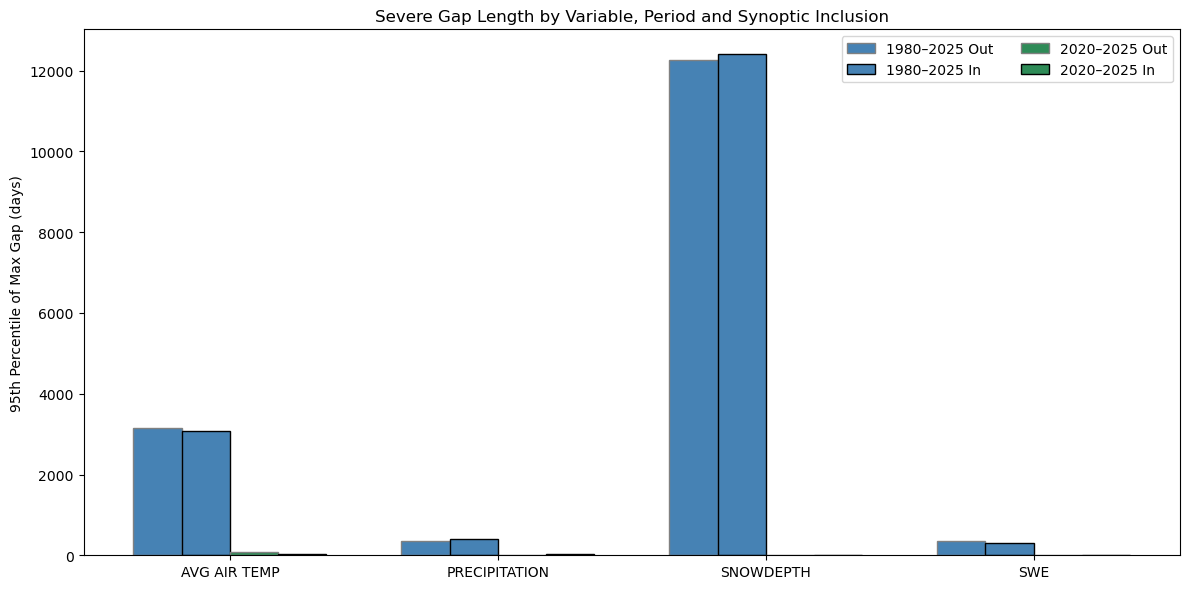

In [48]:
import matplotlib.pyplot as plt
import numpy as np

gap_summary = (
    df_combined
    .groupby(["column_used", "syn_in"])[
        ["max_gap_days_1980", "max_gap_days_2020"]
    ]
    .quantile(0.95)
    .reset_index()
)

variables = gap_summary["column_used"].unique()
x = np.arange(len(variables))
width = 0.18

fig, ax = plt.subplots(figsize=(12,6))

for i, var in enumerate(variables):

    sub = gap_summary[gap_summary["column_used"] == var]

    g80_out = sub.loc[sub["syn_in"]==False, "max_gap_days_1980"].values
    g80_in  = sub.loc[sub["syn_in"]==True,  "max_gap_days_1980"].values
    g20_out = sub.loc[sub["syn_in"]==False, "max_gap_days_2020"].values
    g20_in  = sub.loc[sub["syn_in"]==True,  "max_gap_days_2020"].values

    # 1980–2025
    ax.bar(x[i] - 1.5*width, g80_out, width,
           color="steelblue", edgecolor="gray",
           label="1980–2025 Out" if i==0 else "")

    ax.bar(x[i] - 0.5*width, g80_in, width,
           color="steelblue", edgecolor="black",
           label="1980–2025 In" if i==0 else "")

    # 2020–2025
    ax.bar(x[i] + 0.5*width, g20_out, width,
           color="seagreen", edgecolor="gray",
           label="2020–2025 Out" if i==0 else "")

    ax.bar(x[i] + 1.5*width, g20_in, width,
           color="seagreen", edgecolor="black",
           label="2020–2025 In" if i==0 else "")

ax.set_xticks(x)
ax.set_xticklabels(variables)
ax.set_ylabel("95th Percentile of Max Gap (days)")
ax.set_title("Severe Gap Length by Variable, Period and Synoptic Inclusion")
ax.set_ylim(0)

ax.legend(ncol=2)
plt.tight_layout()
plt.show()

In [49]:
df_combined.groupby(["column_used","syn_in"])[
    ["n_gaps_1980","n_gaps_2020"]
].median()

n_gaps_1980  n_gaps_2020
column_used   syn_in                          
AVG AIR TEMP  False          48.0          2.0
              True           45.0          3.0
PRECIPITATION False           1.0          0.0
              True            1.5          0.0
SNOWDEPTH     False           3.0          0.0
              True            2.0          0.0
SWE           False           2.0          0.0
              True            1.0          0.0

## NOTES
Some stations did not measure snow depth at all for several decades.
	•	The calculated max_gap over the 1980–2025 period includes time spans prior to the installation of the snow depth sensor, artificially inflating the apparent gap length.

In [51]:
df_combined["delta_coverage"] = (
    df_combined["coverage_pct_2020"] -
    df_combined["coverage_pct_1980"]
)

df_combined.groupby(["column_used","syn_in"])["delta_coverage"].mean()

column_used    syn_in
AVG AIR TEMP   False     10.112535
               True      11.367692
PRECIPITATION  False      0.532254
               True       0.664615
SNOWDEPTH      False     44.630704
               True      46.896154
SWE            False      0.512676
               True       0.652308
Name: delta_coverage, dtype: float64

In [52]:
df_combined["delta_max_gap"] = (
    df_combined["max_gap_days_2020"] -
    df_combined["max_gap_days_1980"]
)

df_combined.groupby(["column_used","syn_in"])["delta_max_gap"].median()

column_used    syn_in
AVG AIR TEMP   False    -2421.0
               True     -2745.0
PRECIPITATION  False       -9.0
               True        -5.0
SNOWDEPTH      False    -6969.0
               True     -7631.0
SWE            False       -1.0
               True       -10.0
Name: delta_max_gap, dtype: float64

In [53]:
df_combined["reliability_2020"] = (
    df_combined["coverage_pct_2020"] -
    np.log1p(df_combined["max_gap_days_2020"])
)

df_combined.groupby(["column_used","syn_in"])["reliability_2020"].mean()

column_used    syn_in
AVG AIR TEMP   False     97.581003
               True      97.989037
PRECIPITATION  False     99.494942
               True      98.970781
SNOWDEPTH      False     99.426585
               True      99.769801
SWE            False     99.280725
               True      99.884900
Name: reliability_2020, dtype: float64

In [54]:
df_combined.groupby(["column_used","syn_in"])["por_years_1980"].describe()

count       mean        std     min       25%      50%  \
column_used   syn_in                                                           
AVG AIR TEMP  False    71.0  35.937268   5.868105  16.252  36.33650  37.2510   
              True     14.0  30.836071  14.493424   4.235  36.42900  37.2580   
PRECIPITATION False    71.0  40.273000   7.696485  16.249  40.24900  44.2490   
              True     14.0  35.363643  16.943808   4.233  38.66425  44.2230   
SNOWDEPTH     False    71.0  21.220592   5.645758   8.542  16.30950  23.2500   
              True     14.0  16.444571   8.848785   4.233   9.13750  17.2705   
SWE           False    71.0  40.341493   7.750605  16.252  40.32850  44.2490   
              True     14.0  35.550214  17.046754   4.233  38.74850  44.2490   

                           75%     max  
column_used   syn_in                    
AVG AIR TEMP  False   37.72750  45.391  
              True    37.30625  43.192  
PRECIPITATION False   44.24900  45.248  
              True    44.99825  45.990  
SNOWDEPTH     False   25.54150  29.248  
              True    23.48600  29.394  
SWE           False   45.24800  45.248  
              True    45.24800  45.990

In [56]:
df_combined.sort_values("max_gap_days_1980", ascending=False).head(10)

,station_triplet,column_used,coverage_pct_2020,por_start_2020,por_end_2020,por_years_2020,n_gaps_2020,max_gap_days_2020,note_2020,error_2020,...,max_gap_days_1980,note_1980,error_1980,station_id,syn_in_x,syn_in_y,syn_in,delta_coverage,delta_max_gap,reliability_2020
101,492:ID:SNTL,SNOWDEPTH,100.0,2020-01-01 08:00:00+00:00,2025-12-31 08:00:00+00:00,5.999,0.0,0.0,NaN,NaN,...,13483,NaN,NaN,492,True,True,True,81.58,-13483.0,100.0
233,704:ID:SNTL,SNOWDEPTH,100.0,2020-01-01 08:00:00+00:00,2025-12-31 08:00:00+00:00,5.999,0.0,0.0,NaN,NaN,...,13010,NaN,NaN,704,False,False,False,80.65,-13010.0,100.0
169,620:ID:SNTL,SNOWDEPTH,100.0,2020-01-01 08:00:00+00:00,2025-12-31 08:00:00+00:00,5.999,0.0,0.0,NaN,NaN,...,12679,NaN,NaN,620,False,False,False,78.63,-12679.0,100.0
185,638:ID:SNTL,SNOWDEPTH,100.0,2020-01-01 08:00:00+00:00,2025-12-31 08:00:00+00:00,5.999,0.0,0.0,NaN,NaN,...,12352,NaN,NaN,638,False,False,False,76.53,-12352.0,100.0
105,493:ID:SNTL,SNOWDEPTH,100.0,2020-01-01 08:00:00+00:00,2025-12-31 08:00:00+00:00,5.999,0.0,0.0,NaN,NaN,...,12329,NaN,NaN,493,False,False,False,76.43,-12329.0,100.0
325,855:ID:SNTL,SNOWDEPTH,100.0,2020-01-01 08:00:00+00:00,2025-12-31 08:00:00+00:00,5.999,0.0,0.0,NaN,NaN,...,12183,NaN,NaN,855,False,False,False,74.45,-12183.0,100.0
277,752:ID:SNTL,SNOWDEPTH,100.0,2020-01-01 08:00:00+00:00,2025-12-31 08:00:00+00:00,5.999,0.0,0.0,NaN,NaN,...,11821,NaN,NaN,752,True,True,True,73.70,-11821.0,100.0
301,792:ID:SNTL,SNOWDEPTH,100.0,2020-01-01 08:00:00+00:00,2025-12-31 08:00:00+00:00,5.999,0.0,0.0,NaN,NaN,...,11683,NaN,NaN,792,True,True,True,74.01,-11683.0,100.0
21,324:ID:SNTL,SNOWDEPTH,100.0,2020-01-01 08:00:00+00:00,2025-12-31 08:00:00+00:00,5.999,0.0,0.0,NaN,NaN,...,11303,NaN,NaN,324,False,False,False,69.93,-11303.0,100.0
193,639:ID:SNTL,SNOWDEPTH,100.0,2020-01-01 08:00:00+00:00,2025-12-31 08:00:00+00:00,5.999,0.0,0.0,NaN,NaN,...,11300,NaN,NaN,639,False,False,False,69.96,-11300.0,100.0


In [57]:
from scipy.stats import mannwhitneyu

for var in df_combined["column_used"].unique():
    sub = df_combined[df_combined["column_used"]==var]
    in_vals = sub[sub["syn_in"]==True]["coverage_pct_2020"]
    out_vals = sub[sub["syn_in"]==False]["coverage_pct_2020"]
    print(var, mannwhitneyu(in_vals, out_vals, alternative="two-sided"))

SWE MannwhitneyuResult(statistic=np.float64(nan), pvalue=np.float64(nan))
SNOWDEPTH MannwhitneyuResult(statistic=np.float64(nan), pvalue=np.float64(nan))
PRECIPITATION MannwhitneyuResult(statistic=np.float64(nan), pvalue=np.float64(nan))
AVG AIR TEMP MannwhitneyuResult(statistic=np.float64(nan), pvalue=np.float64(nan))


In [58]:
station_score = (
    df_combined
    .groupby("station_triplet")["reliability_2020"]
    .mean()
)

[INFO] Outliers mapped: 10 for PRECIPITATION (2020)


,station_triplet,syn_in,coverage_pct_2020,max_gap_days_2020
2,306:ID:SNTL,False,94.30,125.0
222,1299:ID:SNTL,True,94.66,68.0
334,867:ID:SNTL,False,99.22,15.0
14,320:ID:SNTL,False,99.68,6.0
230,695:ID:SNTL,True,99.86,3.0
138,546:ID:SNTL,False,99.72,3.0
282,761:ID:SNTL,False,99.72,3.0
306,803:ID:SNTL,False,99.91,2.0
150,1016:ID:SNTL,False,99.91,2.0
114,520:ID:SNTL,False,99.81,2.0


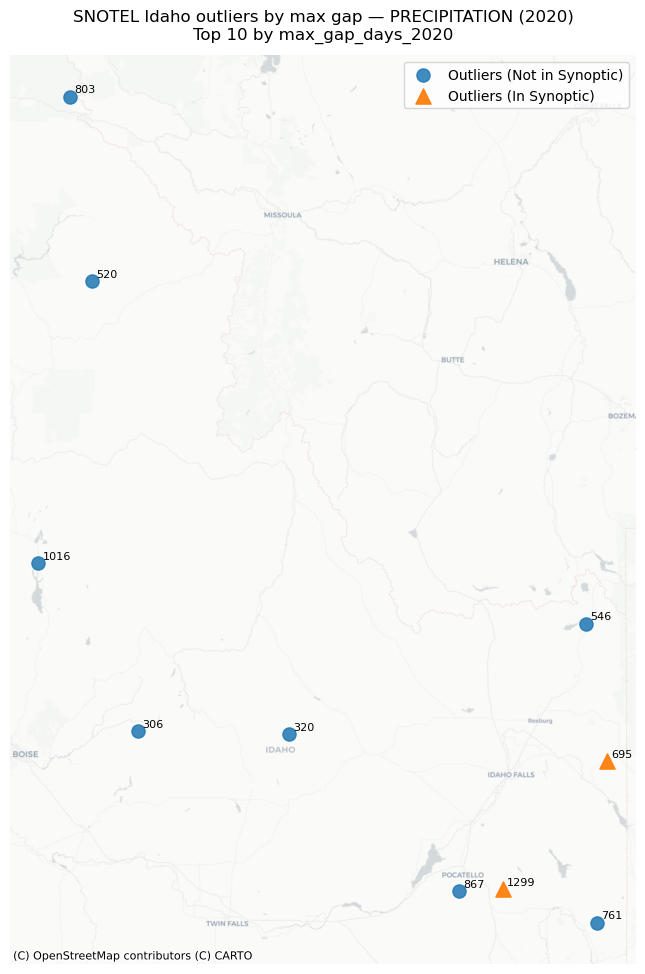

In [59]:
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt
import contextily as cx

# --------------------------
# Helper
# --------------------------
def to_gdf(df, lon_col="lon", lat_col="lat"):
    gdf = gpd.GeoDataFrame(
        df.copy(),
        geometry=[Point(xy) for xy in zip(df[lon_col], df[lat_col])],
        crs="EPSG:4326"
    )
    return gdf.to_crs(epsg=3857)

# --------------------------
# 1) Scegli cosa mappare
# --------------------------
VAR = "PRECIPITATION"          # "SWE", "SNOWDEPTH", "AVG AIR TEMP", "PRECIPITATION"
PERIOD = "2020"                # "2020" oppure "1980"
TOP_N = 10                     # quanti outlier vuoi vedere
MIN_COVERAGE = 0               # opzionale: escludi stazioni con coverage troppo basso

# colonne periodo
maxgap_col = f"max_gap_days_{PERIOD}"
cov_col    = f"coverage_pct_{PERIOD}"

# --------------------------
# 2) Seleziona outlier (top N per max_gap_days nel periodo scelto)
# --------------------------
out = (
    df_combined[df_combined["column_used"] == VAR]
    .copy()
)

# pulizia
out[maxgap_col] = pd.to_numeric(out[maxgap_col], errors="coerce")
out[cov_col]    = pd.to_numeric(out[cov_col], errors="coerce")

out = out[out[cov_col] >= MIN_COVERAGE]
out = out.dropna(subset=[maxgap_col]).sort_values(maxgap_col, ascending=False).head(TOP_N)

print(f"[INFO] Outliers mapped: {len(out)} for {VAR} ({PERIOD})")
display(out[["station_triplet","syn_in", cov_col, maxgap_col]].head(10))

# --------------------------
# 3) Join coordinate da df_snotel_official
#    df_snotel_official ha lat/lon ed anche station_id: usiamo station_triplet -> station_id
# --------------------------
out["station_id"] = (
    out["station_triplet"].astype(str).str.extract(r"(\d+)")[0].astype(float)
)

# df_snotel_official: station_id può essere int o float -> uniformiamo
coords = df_snotel_official.copy()
coords["station_id"] = pd.to_numeric(coords["station_id"], errors="coerce")

out_map = out.merge(
    coords[["station_id","site_name","lat","lon"]],
    on="station_id",
    how="left"
)

# tieni solo quelli con coordinate
out_map = out_map.dropna(subset=["lat","lon"]).copy()

# --------------------------
# 4) Geo + plot
# --------------------------
gdf_out = to_gdf(out_map, lon_col="lon", lat_col="lat")

fig, ax = plt.subplots(figsize=(8, 10))

# due layer: syn_in False vs True
gdf_out[gdf_out["syn_in"] == False].plot(
    ax=ax, markersize=90, alpha=0.85, marker="o", label="Outliers (Not in Synoptic)"
)
gdf_out[gdf_out["syn_in"] == True].plot(
    ax=ax, markersize=120, alpha=0.95, marker="^", label="Outliers (In Synoptic)"
)

# etichette (station_id)
for _, r in gdf_out.iterrows():
    ax.annotate(
        text=str(int(r["station_id"])) if pd.notna(r["station_id"]) else "",
        xy=(r.geometry.x, r.geometry.y),
        xytext=(3, 3),
        textcoords="offset points",
        fontsize=8
    )

cx.add_basemap(ax, source=cx.providers.CartoDB.Positron)
ax.set_axis_off()
ax.set_title(
    f"SNOTEL Idaho outliers by max gap — {VAR} ({PERIOD})\n"
    f"Top {TOP_N} by {maxgap_col}",
    pad=12
)
ax.legend(loc="upper right", frameon=True)
plt.tight_layout()
plt.show()

[INFO] Outliers mapped: 10 for AVG AIR TEMP (2020)


,station_triplet,syn_in,coverage_pct_2020,max_gap_days_2020
295,770:ID:SNTL,False,86.72,139.0
251,735:ID:SNTL,False,94.11,128.0
175,623:ID:SNTL,False,91.97,113.0
323,845:ID:SNTL,False,96.03,83.0
291,769:ID:SNTL,False,96.29,60.0
231,695:ID:SNTL,True,95.01,60.0
59,423:ID:SNTL,False,97.35,52.0
67,425:ID:SNTL,False,97.95,32.0
191,637:ID:SNTL,False,98.71,28.0
255,915:ID:SNTL,False,99.13,19.0


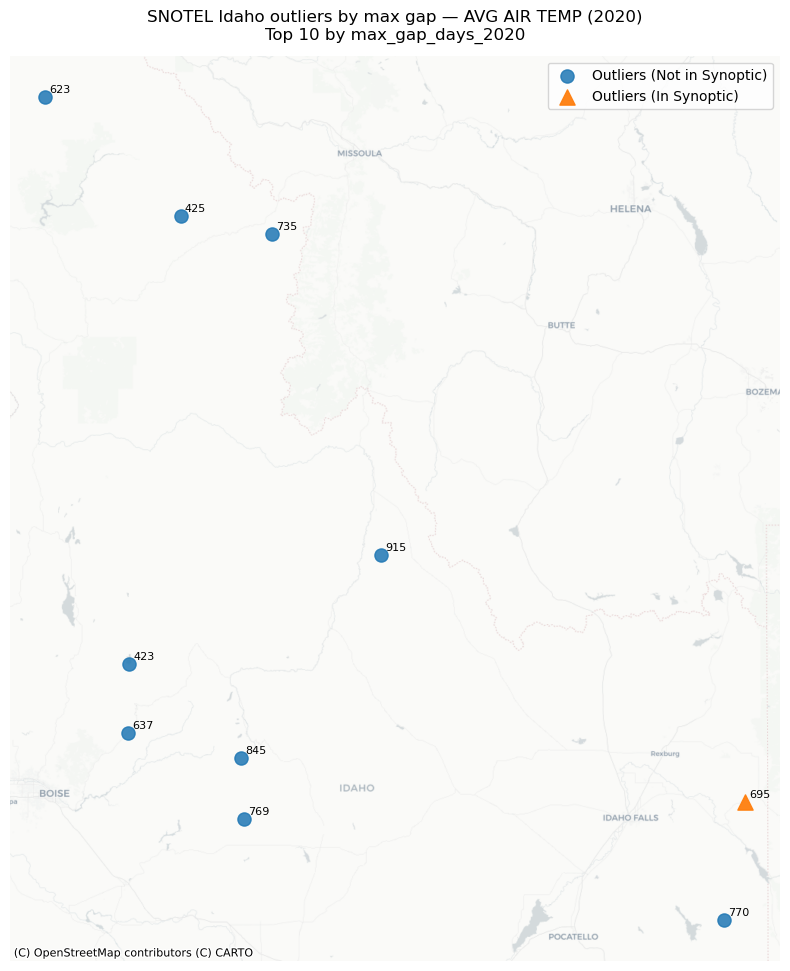

In [60]:
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt
import contextily as cx

# --------------------------
# Helper
# --------------------------
def to_gdf(df, lon_col="lon", lat_col="lat"):
    gdf = gpd.GeoDataFrame(
        df.copy(),
        geometry=[Point(xy) for xy in zip(df[lon_col], df[lat_col])],
        crs="EPSG:4326"
    )
    return gdf.to_crs(epsg=3857)

# --------------------------
# 1) Scegli cosa mappare
# --------------------------
VAR = "AVG AIR TEMP"          # "SWE", "SNOWDEPTH", "AVG AIR TEMP", "PRECIPITATION"
PERIOD = "2020"                # "2020" oppure "1980"
TOP_N = 10                     # quanti outlier vuoi vedere
MIN_COVERAGE = 0               # opzionale: escludi stazioni con coverage troppo basso

# colonne periodo
maxgap_col = f"max_gap_days_{PERIOD}"
cov_col    = f"coverage_pct_{PERIOD}"

# --------------------------
# 2) Seleziona outlier (top N per max_gap_days nel periodo scelto)
# --------------------------
out = (
    df_combined[df_combined["column_used"] == VAR]
    .copy()
)

# pulizia
out[maxgap_col] = pd.to_numeric(out[maxgap_col], errors="coerce")
out[cov_col]    = pd.to_numeric(out[cov_col], errors="coerce")

out = out[out[cov_col] >= MIN_COVERAGE]
out = out.dropna(subset=[maxgap_col]).sort_values(maxgap_col, ascending=False).head(TOP_N)

print(f"[INFO] Outliers mapped: {len(out)} for {VAR} ({PERIOD})")
display(out[["station_triplet","syn_in", cov_col, maxgap_col]].head(10))

# --------------------------
# 3) Join coordinate da df_snotel_official
#    df_snotel_official ha lat/lon ed anche station_id: usiamo station_triplet -> station_id
# --------------------------
out["station_id"] = (
    out["station_triplet"].astype(str).str.extract(r"(\d+)")[0].astype(float)
)

# df_snotel_official: station_id può essere int o float -> uniformiamo
coords = df_snotel_official.copy()
coords["station_id"] = pd.to_numeric(coords["station_id"], errors="coerce")

out_map = out.merge(
    coords[["station_id","site_name","lat","lon"]],
    on="station_id",
    how="left"
)

# tieni solo quelli con coordinate
out_map = out_map.dropna(subset=["lat","lon"]).copy()

# --------------------------
# 4) Geo + plot
# --------------------------
gdf_out = to_gdf(out_map, lon_col="lon", lat_col="lat")

fig, ax = plt.subplots(figsize=(8, 10))

# due layer: syn_in False vs True
gdf_out[gdf_out["syn_in"] == False].plot(
    ax=ax, markersize=90, alpha=0.85, marker="o", label="Outliers (Not in Synoptic)"
)
gdf_out[gdf_out["syn_in"] == True].plot(
    ax=ax, markersize=120, alpha=0.95, marker="^", label="Outliers (In Synoptic)"
)

# etichette (station_id)
for _, r in gdf_out.iterrows():
    ax.annotate(
        text=str(int(r["station_id"])) if pd.notna(r["station_id"]) else "",
        xy=(r.geometry.x, r.geometry.y),
        xytext=(3, 3),
        textcoords="offset points",
        fontsize=8
    )

cx.add_basemap(ax, source=cx.providers.CartoDB.Positron)
ax.set_axis_off()
ax.set_title(
    f"SNOTEL Idaho outliers by max gap — {VAR} ({PERIOD})\n"
    f"Top {TOP_N} by {maxgap_col}",
    pad=12
)
ax.legend(loc="upper right", frameon=True)
plt.tight_layout()
plt.show()

[INFO] Outliers mapped: 10 for SWE (2020)


,station_triplet,syn_in,coverage_pct_2020,max_gap_days_2020
56,423:ID:SNTL,False,81.52,405.0
252,915:ID:SNTL,False,89.92,221.0
44,895:ID:SNTL,False,99.68,7.0
280,761:ID:SNTL,False,99.91,2.0
240,1081:ID:SNTL,False,99.91,1.0
136,546:ID:SNTL,False,99.91,1.0
228,695:ID:SNTL,True,99.95,1.0
288,769:ID:SNTL,False,99.95,1.0
148,1016:ID:SNTL,False,99.95,1.0
112,520:ID:SNTL,False,99.95,1.0


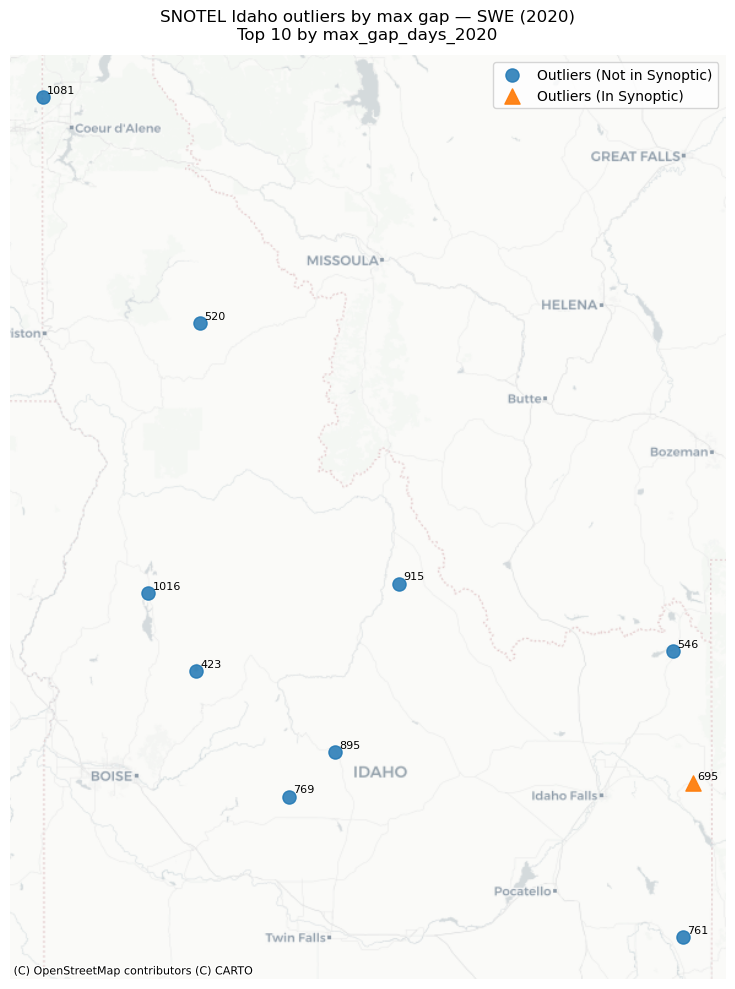

In [61]:
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt
import contextily as cx

# --------------------------
# Helper
# --------------------------
def to_gdf(df, lon_col="lon", lat_col="lat"):
    gdf = gpd.GeoDataFrame(
        df.copy(),
        geometry=[Point(xy) for xy in zip(df[lon_col], df[lat_col])],
        crs="EPSG:4326"
    )
    return gdf.to_crs(epsg=3857)

# --------------------------
# 1) Scegli cosa mappare
# --------------------------
VAR = "SWE"          # "SWE", "SNOWDEPTH", "AVG AIR TEMP", "PRECIPITATION"
PERIOD = "2020"                # "2020" oppure "1980"
TOP_N = 10                     # quanti outlier vuoi vedere
MIN_COVERAGE = 0               # opzionale: escludi stazioni con coverage troppo basso

# colonne periodo
maxgap_col = f"max_gap_days_{PERIOD}"
cov_col    = f"coverage_pct_{PERIOD}"

# --------------------------
# 2) Seleziona outlier (top N per max_gap_days nel periodo scelto)
# --------------------------
out = (
    df_combined[df_combined["column_used"] == VAR]
    .copy()
)

# pulizia
out[maxgap_col] = pd.to_numeric(out[maxgap_col], errors="coerce")
out[cov_col]    = pd.to_numeric(out[cov_col], errors="coerce")

out = out[out[cov_col] >= MIN_COVERAGE]
out = out.dropna(subset=[maxgap_col]).sort_values(maxgap_col, ascending=False).head(TOP_N)

print(f"[INFO] Outliers mapped: {len(out)} for {VAR} ({PERIOD})")
display(out[["station_triplet","syn_in", cov_col, maxgap_col]].head(10))

# --------------------------
# 3) Join coordinate da df_snotel_official
#    df_snotel_official ha lat/lon ed anche station_id: usiamo station_triplet -> station_id
# --------------------------
out["station_id"] = (
    out["station_triplet"].astype(str).str.extract(r"(\d+)")[0].astype(float)
)

# df_snotel_official: station_id può essere int o float -> uniformiamo
coords = df_snotel_official.copy()
coords["station_id"] = pd.to_numeric(coords["station_id"], errors="coerce")

out_map = out.merge(
    coords[["station_id","site_name","lat","lon"]],
    on="station_id",
    how="left"
)

# tieni solo quelli con coordinate
out_map = out_map.dropna(subset=["lat","lon"]).copy()

# --------------------------
# 4) Geo + plot
# --------------------------
gdf_out = to_gdf(out_map, lon_col="lon", lat_col="lat")

fig, ax = plt.subplots(figsize=(8, 10))

# due layer: syn_in False vs True
gdf_out[gdf_out["syn_in"] == False].plot(
    ax=ax, markersize=90, alpha=0.85, marker="o", label="Outliers (Not in Synoptic)"
)
gdf_out[gdf_out["syn_in"] == True].plot(
    ax=ax, markersize=120, alpha=0.95, marker="^", label="Outliers (In Synoptic)"
)

# etichette (station_id)
for _, r in gdf_out.iterrows():
    ax.annotate(
        text=str(int(r["station_id"])) if pd.notna(r["station_id"]) else "",
        xy=(r.geometry.x, r.geometry.y),
        xytext=(3, 3),
        textcoords="offset points",
        fontsize=8
    )

cx.add_basemap(ax, source=cx.providers.CartoDB.Positron)
ax.set_axis_off()
ax.set_title(
    f"SNOTEL Idaho outliers by max gap — {VAR} ({PERIOD})\n"
    f"Top {TOP_N} by {maxgap_col}",
    pad=12
)
ax.legend(loc="upper right", frameon=True)
plt.tight_layout()
plt.show()

[INFO] Outliers mapped: 10 for SNOWDEPTH (2020)


,station_triplet,syn_in,coverage_pct_2020,max_gap_days_2020
253,915:ID:SNTL,False,88.59,249.0
337,871:ID:SNTL,False,98.95,23.0
113,520:ID:SNTL,False,98.84,15.0
61,424:ID:SNTL,False,99.59,9.0
305,803:ID:SNTL,False,99.63,6.0
333,867:ID:SNTL,False,99.91,2.0
281,761:ID:SNTL,False,99.91,2.0
229,695:ID:SNTL,True,99.95,1.0
137,546:ID:SNTL,False,99.91,1.0
265,741:ID:SNTL,False,99.95,1.0


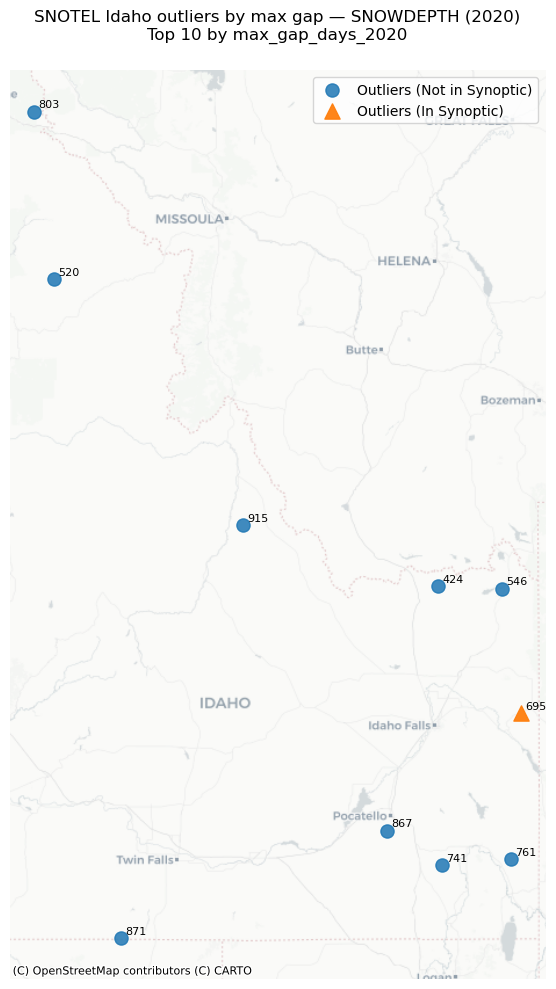

In [62]:
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt
import contextily as cx

# --------------------------
# Helper
# --------------------------
def to_gdf(df, lon_col="lon", lat_col="lat"):
    gdf = gpd.GeoDataFrame(
        df.copy(),
        geometry=[Point(xy) for xy in zip(df[lon_col], df[lat_col])],
        crs="EPSG:4326"
    )
    return gdf.to_crs(epsg=3857)

# --------------------------
# 1) Scegli cosa mappare
# --------------------------
VAR = "SNOWDEPTH"          # "SWE", "SNOWDEPTH", "AVG AIR TEMP", "PRECIPITATION"
PERIOD = "2020"                # "2020" oppure "1980"
TOP_N = 10                     # quanti outlier vuoi vedere
MIN_COVERAGE = 0               # opzionale: escludi stazioni con coverage troppo basso

# colonne periodo
maxgap_col = f"max_gap_days_{PERIOD}"
cov_col    = f"coverage_pct_{PERIOD}"

# --------------------------
# 2) Seleziona outlier (top N per max_gap_days nel periodo scelto)
# --------------------------
out = (
    df_combined[df_combined["column_used"] == VAR]
    .copy()
)

# pulizia
out[maxgap_col] = pd.to_numeric(out[maxgap_col], errors="coerce")
out[cov_col]    = pd.to_numeric(out[cov_col], errors="coerce")

out = out[out[cov_col] >= MIN_COVERAGE]
out = out.dropna(subset=[maxgap_col]).sort_values(maxgap_col, ascending=False).head(TOP_N)

print(f"[INFO] Outliers mapped: {len(out)} for {VAR} ({PERIOD})")
display(out[["station_triplet","syn_in", cov_col, maxgap_col]].head(10))

# --------------------------
# 3) Join coordinate da df_snotel_official
#    df_snotel_official ha lat/lon ed anche station_id: usiamo station_triplet -> station_id
# --------------------------
out["station_id"] = (
    out["station_triplet"].astype(str).str.extract(r"(\d+)")[0].astype(float)
)

# df_snotel_official: station_id può essere int o float -> uniformiamo
coords = df_snotel_official.copy()
coords["station_id"] = pd.to_numeric(coords["station_id"], errors="coerce")

out_map = out.merge(
    coords[["station_id","site_name","lat","lon"]],
    on="station_id",
    how="left"
)

# tieni solo quelli con coordinate
out_map = out_map.dropna(subset=["lat","lon"]).copy()

# --------------------------
# 4) Geo + plot
# --------------------------
gdf_out = to_gdf(out_map, lon_col="lon", lat_col="lat")

fig, ax = plt.subplots(figsize=(8, 10))

# due layer: syn_in False vs True
gdf_out[gdf_out["syn_in"] == False].plot(
    ax=ax, markersize=90, alpha=0.85, marker="o", label="Outliers (Not in Synoptic)"
)
gdf_out[gdf_out["syn_in"] == True].plot(
    ax=ax, markersize=120, alpha=0.95, marker="^", label="Outliers (In Synoptic)"
)

# etichette (station_id)
for _, r in gdf_out.iterrows():
    ax.annotate(
        text=str(int(r["station_id"])) if pd.notna(r["station_id"]) else "",
        xy=(r.geometry.x, r.geometry.y),
        xytext=(3, 3),
        textcoords="offset points",
        fontsize=8
    )

cx.add_basemap(ax, source=cx.providers.CartoDB.Positron)
ax.set_axis_off()
ax.set_title(
    f"SNOTEL Idaho outliers by max gap — {VAR} ({PERIOD})\n"
    f"Top {TOP_N} by {maxgap_col}",
    pad=12
)
ax.legend(loc="upper right", frameon=True)
plt.tight_layout()
plt.show()

First valid: 1995-09-27 08:00:00+00:00
Last valid : 2025-12-31 08:00:00+00:00
Coverage   : 100.0 %


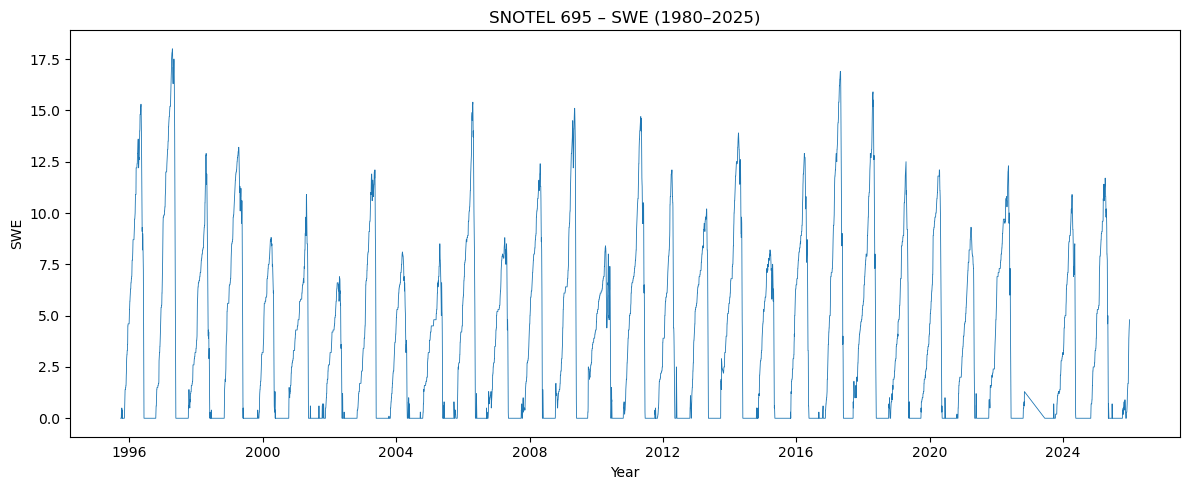

In [65]:
from datetime import datetime
import pandas as pd
import matplotlib.pyplot as plt
from metloom.pointdata import SnotelPointData

# -----------------------------
# CONFIG
# -----------------------------
TRIPLET = "915:ID:SNTL"
START = datetime(1980, 1, 1)
END   = datetime(2025, 12, 31)

VAR = SnotelPointData.ALLOWED_VARIABLES.SWE

# -----------------------------
# Fetch data
# -----------------------------
s = SnotelPointData(station_id=TRIPLET, name=TRIPLET)

df = s.get_daily_data(
    start_date=START,
    end_date=END,
    variables=[VAR]
)

# metloom spesso ritorna MultiIndex (datetime, station)
if isinstance(df.index, pd.MultiIndex):
    df.index = df.index.get_level_values(0)

series = df["SWE"].sort_index()

print("First valid:", series.first_valid_index())
print("Last valid :", series.last_valid_index())
print("Coverage   :", round(100 * series.notna().mean(), 2), "%")

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(12,5))
plt.plot(series.index, series, linewidth=0.6)
plt.title("SNOTEL 915 – SWE (1980–2025)")
plt.ylabel("SWE")
plt.xlabel("Year")
plt.tight_layout()
plt.show()

First valid: 1995-09-27 08:00:00+00:00
Last valid : 2025-12-31 08:00:00+00:00
Coverage   : 100.0 %


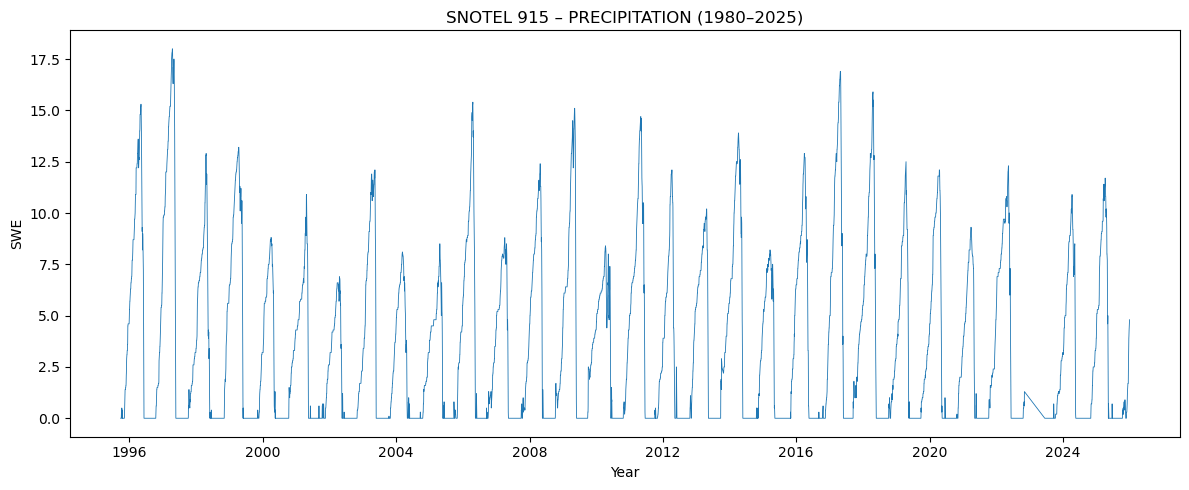

In [67]:
from datetime import datetime
import pandas as pd
import matplotlib.pyplot as plt
from metloom.pointdata import SnotelPointData

# -----------------------------
# CONFIG
# -----------------------------
TRIPLET = "915:ID:SNTL"
START = datetime(1980, 1, 1)
END   = datetime(2025, 12, 31)

VAR = SnotelPointData.ALLOWED_VARIABLES.SWE

# -----------------------------
# Fetch data
# -----------------------------
s = SnotelPointData(station_id=TRIPLET, name=TRIPLET)

df = s.get_daily_data(
    start_date=START,
    end_date=END,
    variables=[VAR]
)

# metloom spesso ritorna MultiIndex (datetime, station)
if isinstance(df.index, pd.MultiIndex):
    df.index = df.index.get_level_values(0)

series = df["SWE"].sort_index()

print("First valid:", series.first_valid_index())
print("Last valid :", series.last_valid_index())
print("Coverage   :", round(100 * series.notna().mean(), 2), "%")

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(12,5))
plt.plot(series.index, series, linewidth=0.6)
plt.title("SNOTEL 915 – PRECIPITATION (1980–2025)")
plt.ylabel("SWE")
plt.xlabel("Year")
plt.tight_layout()
plt.show()

# NEXT STEPS
### SNOTEL Metadata and Network Analysis – Next Analytical Steps

The preliminary quality assessment (coverage, gap frequency, and gap severity) provides insight into operational reliability. However, a comprehensive evaluation of the Idaho SNOTEL network requires a broader metadata-driven analysis. The following analytical directions outline the next steps for a structural and operational assessment of the network.

⸻

1. Network Structure and Spatial Distribution

Elevation Distribution

SNOTEL stations are primarily located in high-elevation environments. An analysis of elevation statistics (mean, range, distribution) can reveal whether the network disproportionately samples specific altitude bands and whether elevation correlates with data continuity or gap severity.

Spatial Density and Clustering

By analyzing nearest-neighbor distances and spatial clustering, we can quantify:
	•	Redundancy in densely instrumented mountain regions
	•	Under-sampled basins or elevation bands
	•	Potential spatial gaps in statewide hydrometeorological coverage

Mapping the stations alongside other networks (e.g., Synoptic, RWIS) allows identification of spatial overlap and structural deficiencies.

Basin (HUC) Coverage

Evaluating station distribution across hydrologic units helps determine whether watershed-scale processes are uniformly monitored or whether certain basins lack adequate snow and precipitation observations.

⸻

2. Temporal Structure of the Network

Installation Timeline

Analyzing the distribution of installation years provides insight into network growth phases. This helps identify:
	•	Expansion waves (e.g., late 1970s–1980s)
	•	Periods of stagnation
	•	Recent additions

Period of Record (POR) and Longevity

Assessing por_years across stations allows evaluation of:
	•	Long-term climate monitoring capacity
	•	Stability of instrumentation
	•	Whether longer-running stations exhibit increased interruption frequency

This temporal perspective distinguishes structural age from operational reliability.
3. Variable Availability Across Stations

Not all SNOTEL stations measure the same variables. A systematic review of variable presence (e.g., SWE, SNOWDEPTH, PRECIPITATION, soil moisture, temperature profiles) allows quantification of:
	•	Percentage of stations measuring each variable
	•	Depth availability for soil moisture sensors
	•	Completeness of temperature profile instrumentation

This analysis reveals whether the network is structurally homogeneous or heterogeneous in sensor deployment.

⸻

4. Operational Reliability Assessment

Beyond structural metadata, operational reliability should be evaluated through:
	•	Coverage percentage (recent vs historical)
	•	Maximum gap length
	•	Gap frequency
	•	Distinction between structural gaps (pre-installation) and operational interruptions

Combining these metrics enables development of a composite Operational Reliability Index, integrating coverage and interruption severity.

⸻

5. Synoptic Inclusion Bias

Given that only a subset of Idaho SNOTEL stations appears in the Synoptic network, it is important to evaluate whether inclusion is associated with:
	•	Higher coverage
	•	Lower gap severity
	•	Greater longevity
	•	Specific elevation bands
	•	Geographic clustering

Statistical comparisons between syn_in and syn_out groups can clarify whether Synoptic selection reflects data quality, metadata characteristics, or other structural factors.

